# Support Vector Machine: Pass/Fail Prediction

This notebook implements an SVM classifier for binary classification. The model predicts whether a student will pass or fail based on multiple features: study hours, attendance, and sleep hours.

The notebook includes the required sections: Problem Statement, Understanding of Dataset, Theory, Mathematical Representation, Diagram, Pseudocode, Expected Output, and Obtained Output. It also includes data cleaning, EDA, feature scaling, feature engineering, and evaluation using accuracy and a confusion matrix.

In [10]:
# Imports and Synthetic CSV Generation
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

DATA_PATH = "student_svm_pass_fail.csv"
FEATURE_COLS = ["study_hours", "attendance", "sleep_hours"]
TARGET_COL = "result"

if not os.path.exists(DATA_PATH):
    np.random.seed(42)
    n = 220
    study_hours = np.round(np.random.uniform(0, 12, n), 2)
    attendance = np.round(np.random.uniform(40, 100, n), 2)
    sleep_hours = np.round(np.random.uniform(4, 10, n), 2)

    score = 0.55 * study_hours + 0.04 * attendance + 0.2 * sleep_hours + np.random.normal(0, 0.8, n)
    result = (score >= 6.0).astype(int)

    df_sample = pd.DataFrame({
        "study_hours": study_hours,
        "attendance": attendance,
        "sleep_hours": sleep_hours,
        TARGET_COL: result
    })
    df_sample.to_csv(DATA_PATH, index=False)
    print(f"✓ Sample CSV created: {DATA_PATH} with {n} samples")
else:
    print(f"✓ Found existing {DATA_PATH}, will use it")

print(f"\nFirst 5 rows of {DATA_PATH}:")
print(pd.read_csv(DATA_PATH).head())

✓ Found existing student_svm_pass_fail.csv, will use it

First 5 rows of student_svm_pass_fail.csv:
   study_hours  attendance  sleep_hours  result
0         4.49       79.46         4.51       0
1        11.41       74.10         9.92       1
2         8.78       45.62         6.25       1
3         7.18       62.06         6.22       1
4         1.87       55.91         8.88       0


## 1. Problem Statement

Build an SVM model to classify students as pass or fail based on study hours, attendance, and sleep hours. Evaluate the model using accuracy and a confusion matrix.

## 2. Understanding of Dataset

Load the dataset and inspect the structure, data types, and summary statistics.

In [11]:
df = pd.read_csv(DATA_PATH)

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print("\nFirst 10 rows:")
print(df.head(10))

print(f"\nDataset shape: {df.shape}")
print(f"Samples: {df.shape[0]}, Features: {df.shape[1]}")

print("\nColumn data types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe().T)

print("\nClass Distribution:")
print(df[TARGET_COL].value_counts())

DATASET OVERVIEW

First 10 rows:
   study_hours  attendance  sleep_hours  result
0         4.49       79.46         4.51       0
1        11.41       74.10         9.92       1
2         8.78       45.62         6.25       1
3         7.18       62.06         6.22       1
4         1.87       55.91         8.88       0
5         1.87       54.64         9.68       0
6         0.70       98.38         9.92       1
7        10.39       63.59         8.52       1
8         7.21       93.52         6.26       1
9         8.50       77.87         4.50       1

Dataset shape: (220, 4)
Samples: 220, Features: 4

Column data types:
study_hours    float64
attendance     float64
sleep_hours    float64
result           int64
dtype: object

Statistical Summary:
             count       mean        std    min      25%     50%      75%  \
study_hours  220.0   5.769364   3.537432   0.06   2.7125   5.955   8.7650   
attendance   220.0  70.392318  17.717500  40.65  56.6625  71.605  85.3200   
sleep_hou

## 3. Data Cleaning

Check for missing values, duplicates, and invalid values.

In [12]:
print("="*60)
print("DATA CLEANING")
print("="*60)

print("\n1. Missing Values Check:")
missing = df.isnull().sum()
print(f"Missing values per column:\n{missing}")
if missing.sum() == 0:
    print("✓ No missing values found")
else:
    df = df.dropna()

print("\n2. Duplicate Rows Check:")
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"× Removed {dupes} duplicate(s)")
else:
    print("✓ No duplicates found")

print("\n3. Invalid Values Check:")
invalid_study = (df["study_hours"] < 0).sum()
invalid_attendance = ((df["attendance"] < 0) | (df["attendance"] > 100)).sum()
invalid_sleep = (df["sleep_hours"] < 0).sum()
invalid_target = (~df[TARGET_COL].isin([0, 1])).sum()
print(f"Invalid study hours: {invalid_study}")
print(f"Invalid attendance: {invalid_attendance}")
print(f"Invalid sleep hours: {invalid_sleep}")
print(f"Invalid target values: {invalid_target}")

df = df[(df["study_hours"] >= 0) & (df["attendance"] >= 0) & (df["attendance"] <= 100) & (df["sleep_hours"] >= 0)]
df = df[df[TARGET_COL].isin([0, 1])].reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

DATA CLEANING

1. Missing Values Check:
Missing values per column:
study_hours    0
attendance     0
sleep_hours    0
result         0
dtype: int64
✓ No missing values found

2. Duplicate Rows Check:
Duplicate rows: 0
✓ No duplicates found

3. Invalid Values Check:
Invalid study hours: 0
Invalid attendance: 0
Invalid sleep hours: 0
Invalid target values: 0

Dataset shape after cleaning: (220, 4)


## 4. Exploratory Data Analysis (EDA)

Explore how the features relate to the pass/fail result.

EXPLORATORY DATA ANALYSIS


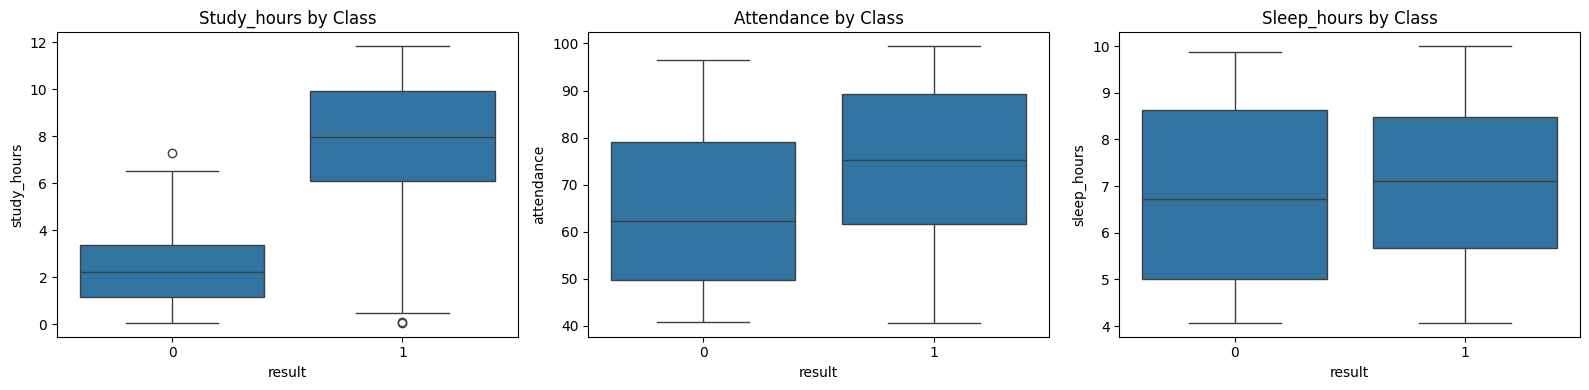

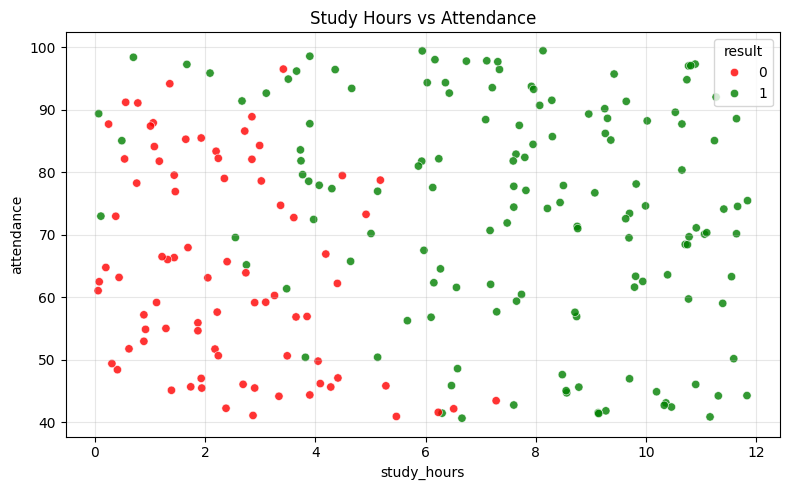


Correlation Matrix:
             study_hours  attendance  sleep_hours    result
study_hours     1.000000    0.010261    -0.070939  0.717292
attendance      0.010261    1.000000    -0.004921  0.263866
sleep_hours    -0.070939   -0.004921     1.000000  0.075912
result          0.717292    0.263866     0.075912  1.000000


In [13]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, col in enumerate(FEATURE_COLS):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[idx])
    axes[idx].set_title(f'{col.capitalize()} by Class')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="study_hours", y="attendance", hue=TARGET_COL, palette={0: 'red', 1: 'green'}, alpha=0.8)
plt.title('Study Hours vs Attendance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = df[FEATURE_COLS + [TARGET_COL]].corr()
print("\nCorrelation Matrix:")
print(corr)

## 5. Feature Engineering & Scaling

Prepare the feature matrix and scale the inputs.

In [14]:
print("="*60)
print("FEATURE ENGINEERING & SCALING")
print("="*60)

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFirst 5 rows of X:")
print(X[:5])
print("\nFirst 5 rows of scaled X:")
print(X_scaled[:5])

FEATURE ENGINEERING & SCALING
X shape: (220, 3)
y shape: (220,)

First 5 rows of X:
[[ 4.49 79.46  4.51]
 [11.41 74.1   9.92]
 [ 8.78 45.62  6.25]
 [ 7.18 62.06  6.22]
 [ 1.87 55.91  8.88]]

First 5 rows of scaled X:
[[-0.36248928  0.51295954 -1.39965325]
 [ 1.59819317  0.20974388  1.63853189]
 [ 0.8530205  -1.40137217 -0.42249204]
 [ 0.39968352 -0.47135996 -0.43933964]
 [-1.10482859 -0.81926599  1.05448152]]


## 6. Theory

Support Vector Machine tries to find the best boundary that separates classes with the largest margin. A linear kernel is used here to keep the notebook simple.

## 7. Mathematical Representation

- Decision function: $f(x) = w^Tx + b$
- Classification rule: predict class 1 if $f(x) e 0$, else class 0
- The SVM finds the hyperplane with maximum margin between classes

## 8. Workflow Diagram

WORKFLOW DIAGRAM


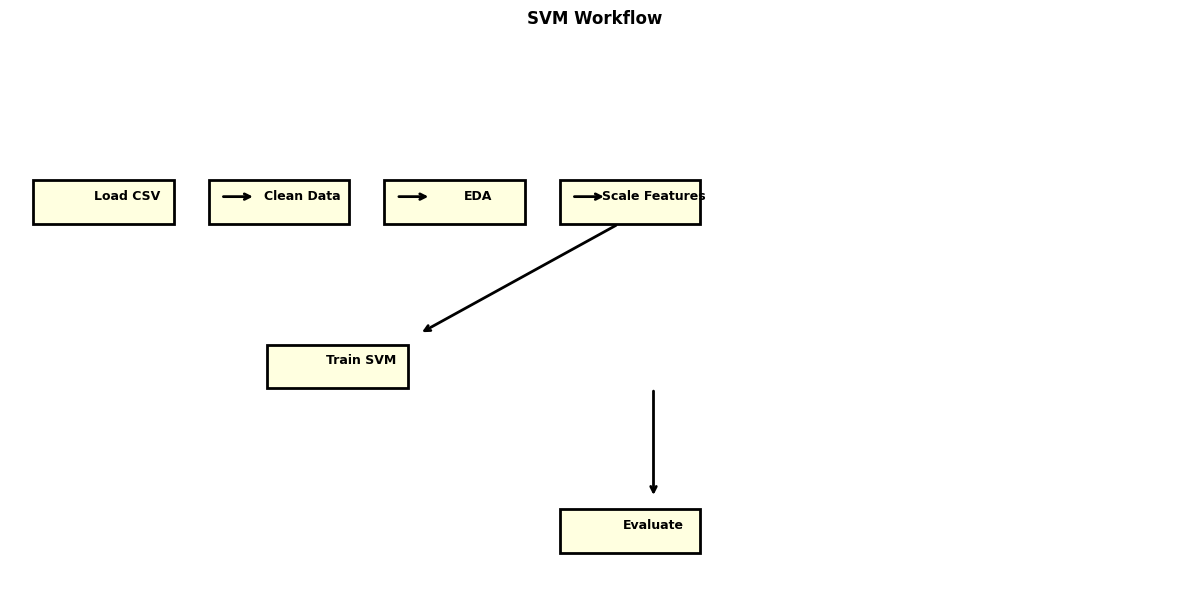

In [15]:
print("="*60)
print("WORKFLOW DIAGRAM")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

from matplotlib.patches import Rectangle
workflow_steps = [
    (0.1, 0.7, "Load CSV"),
    (0.25, 0.7, "Clean Data"),
    (0.4, 0.7, "EDA"),
    (0.55, 0.7, "Scale Features"),
    (0.3, 0.4, "Train SVM"),
    (0.55, 0.1, "Evaluate"),
]

for step_x, step_y, label in workflow_steps:
    rect = Rectangle((step_x - 0.08, step_y - 0.05), 0.12, 0.08, facecolor='lightyellow', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(step_x, step_y, label, ha='center', va='center', fontsize=9, fontweight='bold')

arrows = [((0.18, 0.7), (0.21, 0.7)), ((0.33, 0.7), (0.36, 0.7)), ((0.48, 0.7), (0.51, 0.7)), ((0.52, 0.65), (0.35, 0.45)), ((0.55, 0.35), (0.55, 0.15))]
for start, end in arrows:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.set_title('SVM Workflow', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Pseudocode

```
1. Load the pass/fail dataset
2. Clean and inspect the data
3. Split into features and target
4. Scale the features
5. Split into train and test sets
6. Train an SVM classifier
7. Predict classes on test data
8. Evaluate using accuracy and confusion matrix
9. Save the model and scaler
```

## 10. Train-Test Split and Model Training

In [7]:
print("="*60)
print("TRAIN-TEST SPLIT AND MODEL TRAINING")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples")

model = SVC(kernel='linear')
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Number of support vectors: {len(model.support_vectors_)}")

TRAIN-TEST SPLIT AND MODEL TRAINING
Train size: 176 samples
Test size: 44 samples
Model trained successfully!
Number of support vectors: 49


## 11. Evaluation: Accuracy and Confusion Matrix

In [16]:
print("="*60)
print("MODEL EVALUATION")
print("="*60)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

print("Sample predictions:")
for i in range(min(8, len(y_test))):
    actual = 'Pass' if y_test[i] == 1 else 'Fail'
    predicted = 'Pass' if y_pred[i] == 1 else 'Fail'
    print(f"Actual: {actual:<4} | Predicted: {predicted:<4}")

MODEL EVALUATION
Accuracy: 0.9091

Confusion Matrix:
[[16  0]
 [ 4 24]]

Classification Report:
              precision    recall  f1-score   support

        Fail       0.80      1.00      0.89        16
        Pass       1.00      0.86      0.92        28

    accuracy                           0.91        44
   macro avg       0.90      0.93      0.91        44
weighted avg       0.93      0.91      0.91        44

Sample predictions:
Actual: Fail | Predicted: Fail
Actual: Pass | Predicted: Pass
Actual: Pass | Predicted: Pass
Actual: Pass | Predicted: Fail
Actual: Pass | Predicted: Pass
Actual: Pass | Predicted: Pass
Actual: Pass | Predicted: Fail
Actual: Fail | Predicted: Fail


## 12. Obtained Output

OBTAINED OUTPUT - VISUALIZATIONS


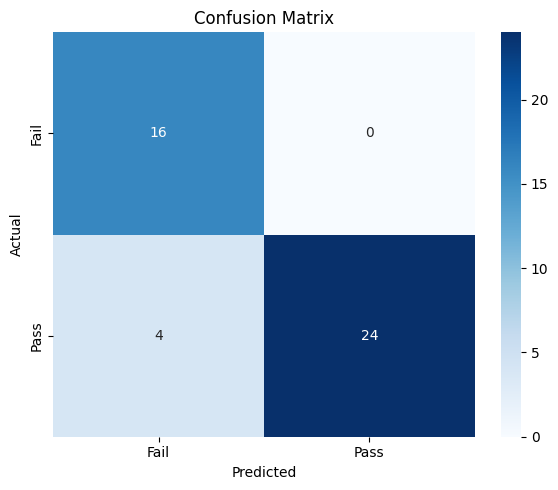

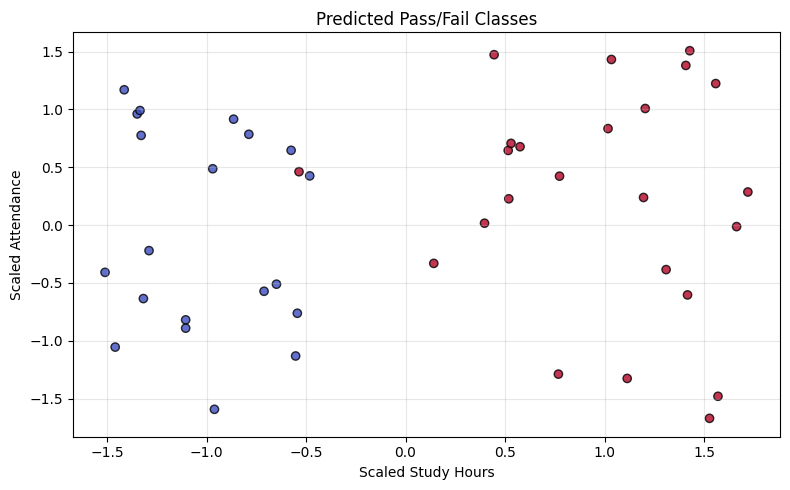


✓ Model and scaler saved successfully

Final Summary:
  Accuracy: 0.9091
  Confusion Matrix:
[[16  0]
 [ 4 24]]


In [17]:
print("="*60)
print("OBTAINED OUTPUT - VISUALIZATIONS")
print("="*60)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', alpha=0.8, edgecolors='black')
plt.xlabel('Scaled Study Hours')
plt.ylabel('Scaled Attendance')
plt.title('Predicted Pass/Fail Classes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

joblib.dump(model, '8_svm_pass_fail_model.joblib')
joblib.dump(scaler, '8_svm_pass_fail_scaler.joblib')

print("\n✓ Model and scaler saved successfully")
print("\nFinal Summary:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Confusion Matrix:\n{cm}")